# Google Search analysis

## New library included : Pytrends
### Pytrends is an unofficial python library that allows easy access to Google trends data through Google's Internal API. Since google doesn't provide an official public API for trends data, Pytrends acts as a smart wrapper aroud Google's web interface, enabling data analysts and developers to extract trend data for various keywords, regions, timeframes.
### specially used for Market Research, trend forecasting, competetive analysis, keyword research, etc
#### know more about it on https://serpapi.com/blog/scraping-google-trends-with-python-pytrends-alternative/

In [37]:
pip install pytrends

Note: you may need to restart the kernel to use updated packages.


In [38]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pytrends.request import TrendReq

In [40]:
# setting up pytrend with keyword for SEO
pytrends = TrendReq(hl = 'en-US', tz = 360)
keyword = input("Enter the keyword : ")

Enter the keyword :  Internship


In [41]:
# requesting data from the google using pytrends.build_payload()
pytrends.build_payload([keyword], cat = 0, timeframe='today 12-m', geo ='', gprop='')

In [42]:
# countrywise interest of the keyword
data = pytrends.interest_by_region()
data = data.sort_values(by=keyword, ascending=False).head(20)

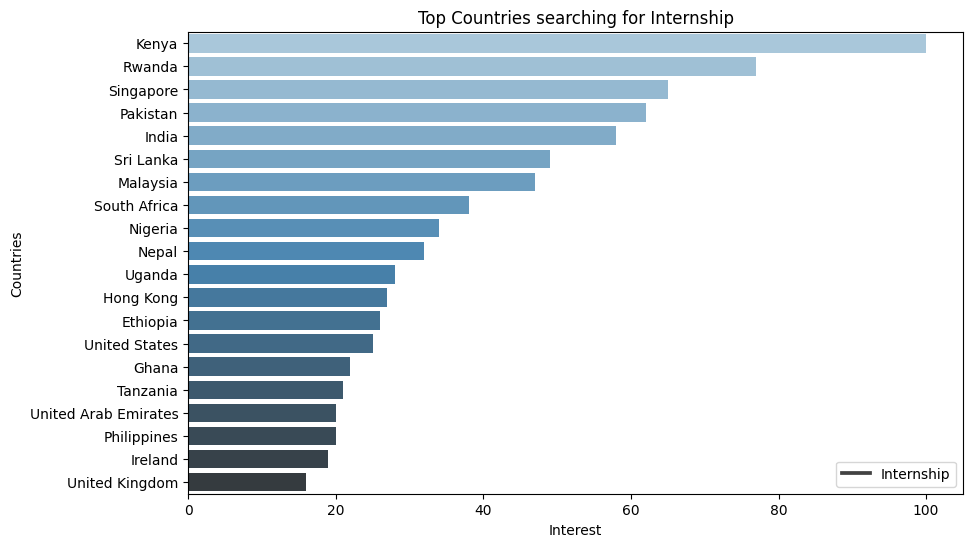

In [43]:
plt.figure(figsize=(10,6))
sns.barplot(x=data[keyword], y = data.index, palette ="Blues_d")
plt.title(f'Top Countries searching for {keyword}')
plt.xlabel("Interest")
plt.ylabel("Countries")
plt.legend(data)
plt.show()

In [44]:
# worldmap
data = data.reset_index()
fig = px.choropleth(
    data,
    locations='geoName',
    locationmode='country names',
    color=keyword,
    title=f"Search interest for '{keyword}' by country",
    color_continuous_scale='Reds'
)
fig.show()

In [45]:
# Time wise interest in keyword
time_df = pytrends.interest_over_time()

/usr/local/lib/python3.11/dist-packages/pytrends/request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



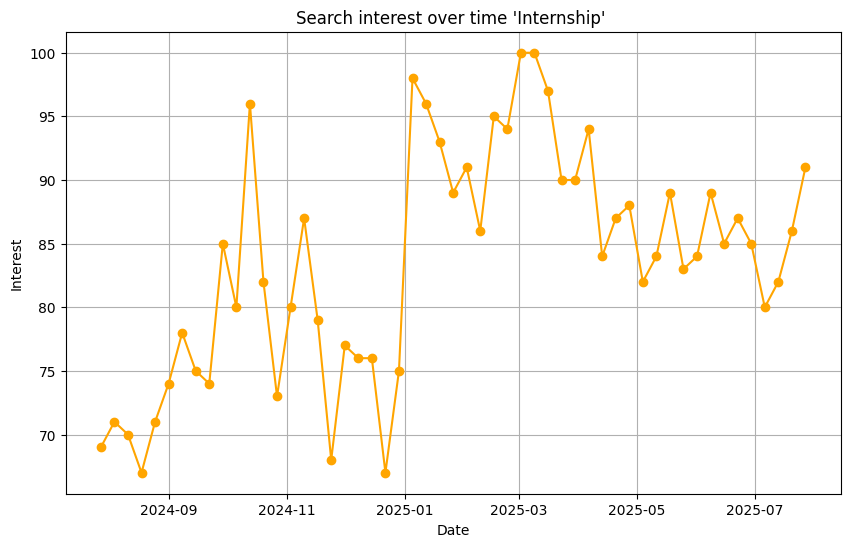

In [46]:
plt.figure(figsize=(10,6))
plt.plot(time_df.index, time_df[keyword], marker='o', color = 'orange')
plt.title(f"Search interest over time '{keyword}' ")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.grid()
plt.show()

In [48]:
# for multiple keywords
kw_list = ["LeetCode", "HackerRank", "Codeforces", "CodeChef"]
pytrends.build_payload(kw_list, cat = 0, timeframe='today 12-m', geo='', gprop='')

/usr/local/lib/python3.11/dist-packages/pytrends/request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



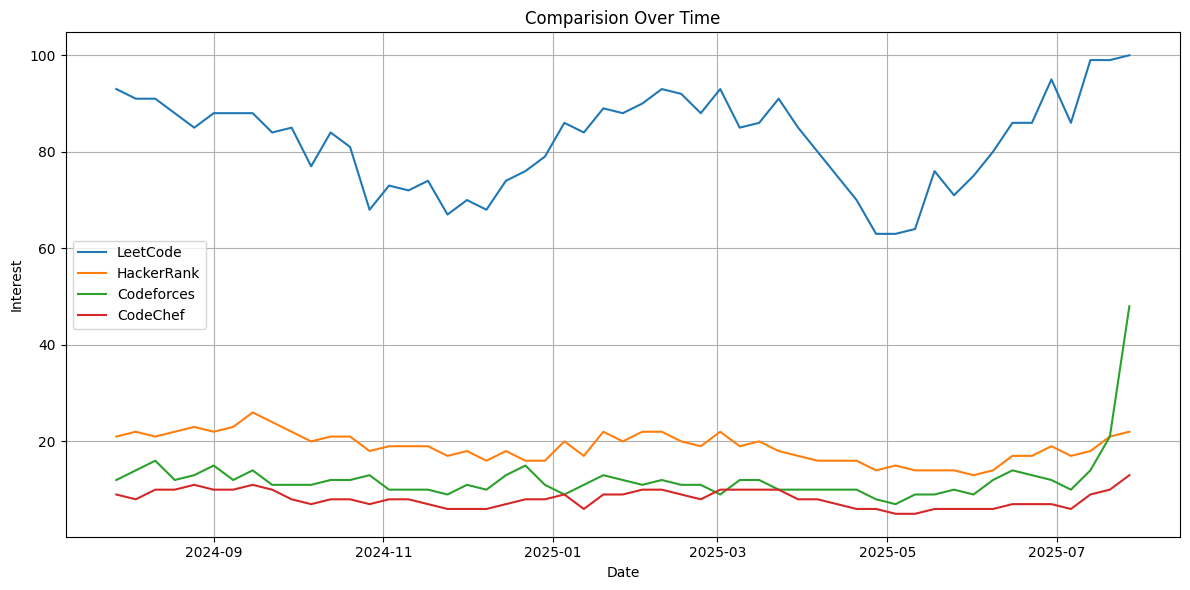

In [49]:
compare_df = pytrends.interest_over_time()
plt.figure(figsize=(12,6))
for kw in kw_list:
    plt.plot(compare_df.index, compare_df[kw], label = kw)

plt.title(f'Comparision Over Time')
plt.xlabel("Date")
plt.ylabel("Interest")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()